In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install keras

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv('cars24_data.csv' , parse_dates=["createdDate"]) # Load the dataset and parse 'createdDate' as datetime
df.sample(10) # Display a random sample of 10 rows to understand the data structure and content

,name,make,model,city,year,fueltype,kilometerdriven,ownernumber,transmission,bodytype,storename,isc24assured,registrationcity,registrationstate,benefits,discountprice,price,url,createdDate
3335,Honda Amaze,Honda,Amaze,New Delhi,2022,Petrol,3031,1,Manual,Sedan,Hi-Multan Nagar,False,Delhi,Delhi,9688,39600,906000,https://www.cars24.com/buy-used-honda-amaze-20...,2022-07-30
1000,Honda CRV,Honda,Crv,Mumbai,2014,Petrol,96699,2,Automatic,Luxury SUV,Hi-West Mumbai,False,Mumbai,Maharashtra,19407,38300,887000,https://www.cars24.com/buy-used-honda-crv-2014...,2022-10-14
1967,Volkswagen Vento,Volkswagen,Vento,Ahmedabad,2021,Petrol,23049,1,Manual,Sedan,Hi-West-Amd,False,Ahmedabad,Gujarat,9688,79800,851000,https://www.cars24.com/buy-used-volkswagen-ven...,2022-05-25
6000,Maruti Dzire,Maruti,Dzire,Hyderabad,2021,Petrol,54918,2,Manual,Sedan,Hi-South Hyd,False,Hyderabad,Telangana,12188,77700,747000,https://www.cars24.com/buy-used-maruti-dzire-2...,2022-09-22
5139,Maruti Swift,Maruti,Swift,Bangalore,2017,Petrol,32918,1,Manual,Hatchback,Hi-North 1 Bengaluru,False,Bangalore,Karnataka,9688,-400,668000,https://www.cars24.com/buy-used-maruti-swift-2...,2022-12-07
3777,Hyundai Verna,Hyundai,Verna,Chennai,2018,Petrol,21302,2,Manual,Sedan,Chennai-Pns,False,Chennai,Tamil Nadu,19407,5000,954000,https://www.cars24.com/buy-used-hyundai-verna-...,2022-11-26
695,Hyundai i20,Hyundai,I20,Ludhiana,2013,Petrol,70282,2,Manual,Hatchback,Hi-Pratap Chowk,False,Ludhiana,Punjab,13898,-38300,389000,https://www.cars24.com/buy-used-hyundai-i20-20...,2022-11-05
4787,Toyota YARIS,Toyota,Yaris,Pune,2018,Petrol,56687,1,Automatic,Sedan,Hi-Pune,False,Pune,Maharashtra,9688,46100,883699,https://www.cars24.com/buy-used-toyota-yaris-2...,2022-11-03
5163,Volkswagen Polo,Volkswagen,Polo,Bangalore,2018,Petrol,88560,1,Manual,Hatchback,Hi-South 3 Bengaluru,False,Bengaluru,Karnataka,12542,-200,690800,https://www.cars24.com/buy-used-volkswagen-pol...,2022-12-06
4298,Volkswagen Vento,Volkswagen,Vento,Bangalore,2016,Petrol,64101,2,Automatic,Sedan,Bengaluru-Pns,False,Bengaluru,Karnataka,13898,12500,861000,https://www.cars24.com/buy-used-volkswagen-ven...,2022-10-29


In [5]:
df_original = df.copy() # Create a copy of the original dataset to preserve it for future reference or comparison

In [6]:
df['listing_year'] = df['createdDate'].dt.year # Extract the year from 'createdDate' and create a new column 'listing_year'
df['car_age'] = df['listing_year'] - df['year'] # Calculate the age of the car by subtracting the manufacturing year from the listing year and create a new column 'car_age'

In [7]:
df.drop(columns=['name', 'url', 'createdDate', 'listing_year'] , inplace= True)  # Drop unnecessary columns that may not contribute to the analysis

In [8]:
df.info() # Check data types and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6437 entries, 0 to 6436
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   make               6437 non-null   object
 1   model              6437 non-null   object
 2   city               6437 non-null   object
 3   year               6437 non-null   int64 
 4   fueltype           6437 non-null   object
 5   kilometerdriven    6437 non-null   int64 
 6   ownernumber        6437 non-null   int64 
 7   transmission       6061 non-null   object
 8   bodytype           6062 non-null   object
 9   storename          6437 non-null   object
 10  isc24assured       6437 non-null   bool  
 11  registrationcity   6437 non-null   object
 12  registrationstate  6437 non-null   object
 13  benefits           6437 non-null   int64 
 14  discountprice      6437 non-null   int64 
 15  price              6437 non-null   int64 
 16  car_age            6437 non-null   int64 


# Handle Missing Values

In [9]:
df.isnull().sum() # Check for missing values in each column

make                   0
model                  0
city                   0
year                   0
fueltype               0
kilometerdriven        0
ownernumber            0
transmission         376
bodytype             375
storename              0
isc24assured           0
registrationcity       0
registrationstate      0
benefits               0
discountprice          0
price                  0
car_age                0
dtype: int64

In [10]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='constant', fill_value='Unknown') # Create an imputer to fill missing values with 'Unknown'
df[['bodytype', 'transmission']] = imputer.fit_transform(df[['bodytype', 'transmission']])  # Impute missing values with 'Unknown'
df.isnull().sum() # Check for remaining missing values

make                 0
model                0
city                 0
year                 0
fueltype             0
kilometerdriven      0
ownernumber          0
transmission         0
bodytype             0
storename            0
isc24assured         0
registrationcity     0
registrationstate    0
benefits             0
discountprice        0
price                0
car_age              0
dtype: int64

# Handle Duplicates

In [11]:
df.duplicated().sum() # Check for duplicate rows

np.int64(17)

In [12]:
df.drop_duplicates(inplace=True) # Remove duplicate rows    
df.duplicated().sum() # Check for duplicate rows after removal

np.int64(0)

# Statistical Summary

In [13]:
df.describe().T #Get summary Statistics of numerical columns

,count,mean,std,min,25%,50%,75%,max
year,6420.0,2017.635670,2.657497,2008.0,2016.00,2018.0,2020.0,2022.0
kilometerdriven,6420.0,41598.630374,26188.446462,64.0,20620.75,38211.5,59362.0,455601.0
ownernumber,6420.0,1.235826,0.454669,1.0,1.00,1.0,1.0,3.0
benefits,6420.0,12081.608723,2459.541202,9688.0,9688.00,12542.0,13898.0,19407.0
discountprice,6420.0,23559.098754,41614.941536,-155500.0,-100.00,10700.0,37100.0,388300.0
price,6420.0,678250.117913,345208.545312,134000.0,438799.75,588000.0,829000.0,3048000.0
car_age,6420.0,4.355919,2.651889,0.0,2.00,4.0,6.0,13.0


# Univariate Analysis

### Numerical Columns

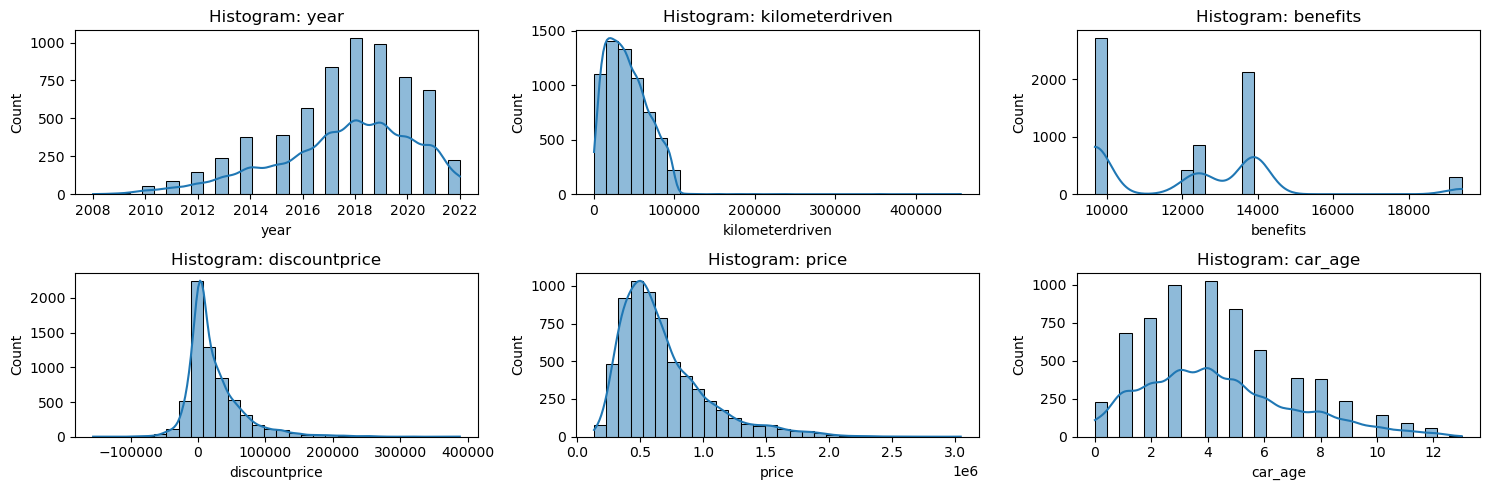

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['year', 'kilometerdriven', 'benefits', 'discountprice', 'price', 'car_age'] 
plt.figure(figsize=(15,5))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2,3, i)
    sns.histplot(df[col], kde=True, bins=30) #Plot Histplot Of Each Numerical Columns TO identify Features Distributions
    plt.title(f"Histogram: {col}")
plt.tight_layout()
plt.show()

### Categorical Columns

In [15]:
cat_cols = df.select_dtypes(include='object').columns.tolist() #Find Categorical Columns 
cat_cols


['make',
 'model',
 'city',
 'fueltype',
 'transmission',
 'bodytype',
 'storename',
 'registrationcity',
 'registrationstate']

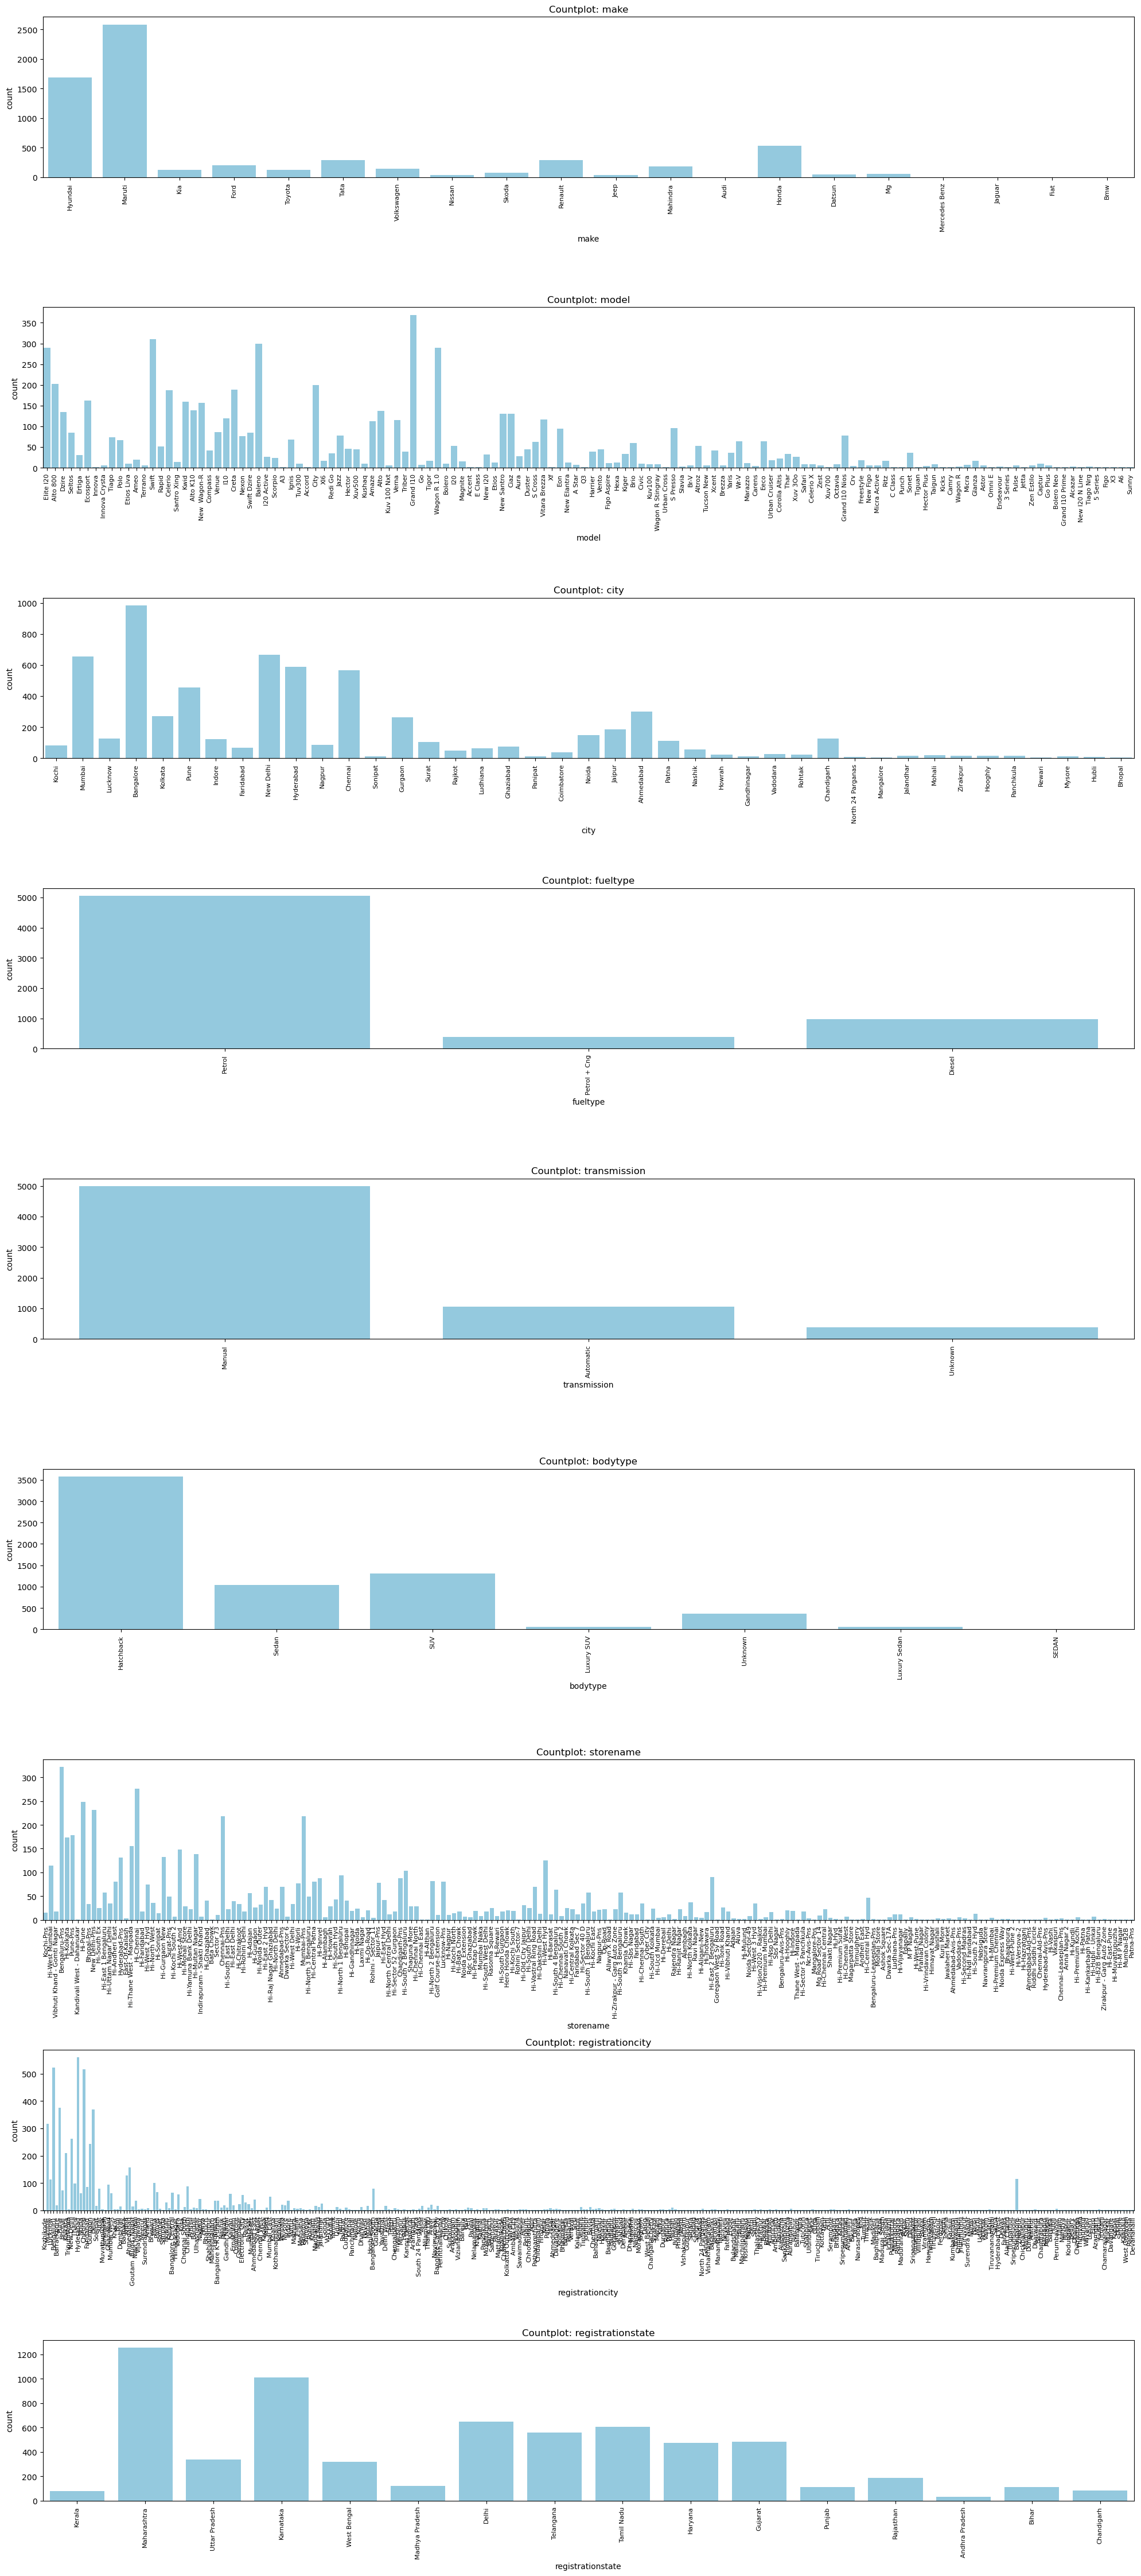

In [16]:
plt.figure(figsize=(20,45))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(9,1, i)
    sns.countplot(x=df[col], color="skyblue") #Plot Countplot Of Each Categorical Column TO identify Features Distributions
    plt.title(f"Countplot: {col}")
    plt.xticks(fontsize=8, rotation=90)
plt.tight_layout()
plt.show()

# Handling Outliers 

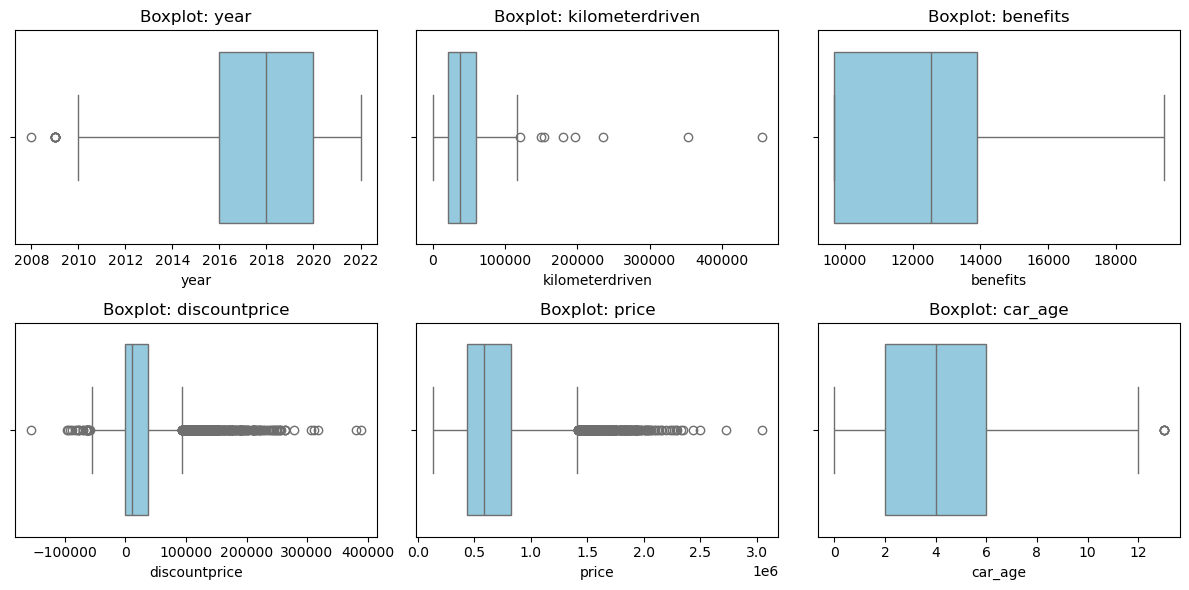

In [17]:
plt.figure(figsize=(12, 6))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col], color="skyblue")  #Plot Boxplot For Outlier Detection 
    plt.title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()

In [18]:
df1 = df.copy()

for col in num_cols :
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    IQR = Q3 - Q1 

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df1[(df1[col] < lower_bound) | (df1[col] > upper_bound)] #Identify Outliers Based on IQR Method
    print(f'{len(outliers)} Outliers in {col}')

10 Outliers in year
8 Outliers in kilometerdriven
0 Outliers in benefits
430 Outliers in discountprice
315 Outliers in price
5 Outliers in car_age


In [19]:
for col in num_cols :
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    IQR = Q3 - Q1 

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df1[col] = df1[col].apply(lambda x: max(min(x, upper_bound), lower_bound)) # capping For handel Outliers 

<Axes: >

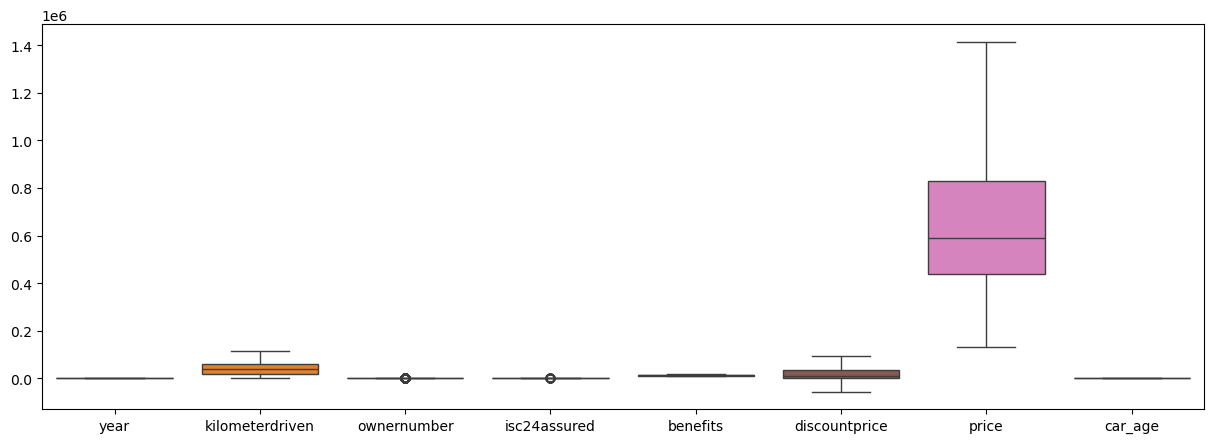

In [20]:
plt.figure(figsize=(15, 5))
sns.boxplot(df1)  #Plot Boxplot For Outlier Detection After Capping

<Axes: >

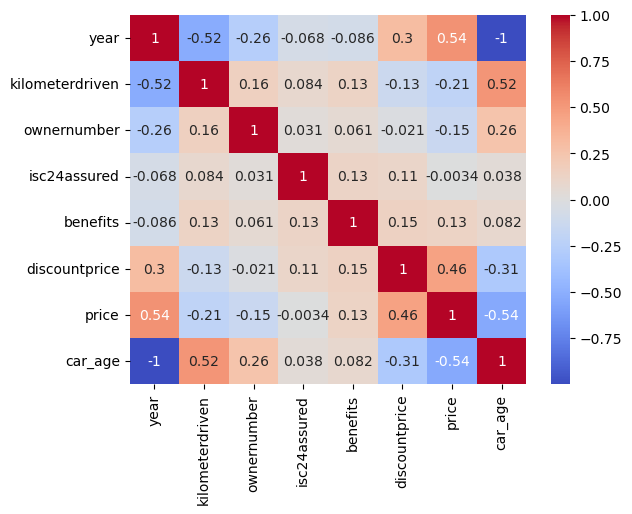

In [21]:
sns.heatmap(df1.corr(numeric_only=True), annot=True, cmap='coolwarm') #Plot Heatmap To Identify Correlation Between Numerical Features

# Encoding Categorical Features

In [22]:
df1.head(2)

,make,model,city,year,fueltype,kilometerdriven,ownernumber,transmission,bodytype,storename,isc24assured,registrationcity,registrationstate,benefits,discountprice,price,car_age
0,Hyundai,Elite I20,Kochi,2017.0,Petrol,35939.0,2,Manual,Hatchback,Kochi-Pns,False,Kozhikode,Kerala,13898,47399.0,607000.0,5.0
1,Maruti,Alto 800,Mumbai,2016.0,Petrol + Cng,6180.0,1,Manual,Hatchback,Hi-West Mumbai,False,Mumbai,Maharashtra,12542,2099.0,326000.0,6.0


In [23]:
df.columns

Index(['make', 'model', 'city', 'year', 'fueltype', 'kilometerdriven',
       'ownernumber', 'transmission', 'bodytype', 'storename', 'isc24assured',
       'registrationcity', 'registrationstate', 'benefits', 'discountprice',
       'price', 'car_age'],
      dtype='object')

In [24]:
more_cat_cols = ['make', 'model', 'city','registrationcity', 'registrationstate','storename'] #Identify Categorical Columns with High Cardinality
less_cat_cols = ['fueltype', 'bodytype', 'transmission'] #Identify Categorical Columns with Low Cardinality

### Train-Test Split

In [25]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']


In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape 

((5136, 16), (1284, 16), (5136,), (1284,))

#### One- Hot Encoding ---> for low cardinality values
#### Target Encoding ---> for High cardinality values

In [27]:
from sklearn.preprocessing import OneHotEncoder,TargetEncoder
from sklearn.compose import ColumnTransformer

In [28]:
# Column Transformer
transformer = ColumnTransformer(
    transformers=[
        ('target', TargetEncoder(), more_cat_cols),   # high cardinality
        ('onehot', OneHotEncoder(handle_unknown='ignore'), less_cat_cols)  # low cardinality
    ],
    remainder='passthrough'
)

In [29]:
## Fit ONLY on training data
transformer.fit(X_train, y_train)

,transformers,"[('target', ...), ('onehot', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,target_type,'auto'
,smooth,'auto'


In [30]:
## Transform both train & test
X_train_transformed = transformer.transform(X_train)
X_test_transformed = transformer.transform(X_test)


#### standard scaling

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train_transformed)

# Transform test data
X_test_scaled = scaler.transform(X_test_transformed)

### MODEL-1. Linear Regression (Use Scaled Data)

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [33]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
### LR model prediction & evaluation on training and testing data 

In [35]:
yhat_train_lr = lr.predict(X_train_scaled)

In [36]:
def eval_regression(y,yhat):
    mse = mean_squared_error(y,yhat)
    rmse = np.sqrt(mse)
    r_sqr = r2_score(y,yhat)
    
    print(f'mean squared error (MSE): {np.round(mse,2)}')
    print(f' Root mean squared error (RMSE): {np.round(rmse,2)}') 
    print(f'R- squared value : {np.round(r_sqr,4)}')

In [37]:
eval_regression(y_train,yhat_train_lr)

mean squared error (MSE): 7432816082.59
 Root mean squared error (RMSE): 86213.78
R- squared value : 0.9373


In [38]:
yhat_test_lr = lr.predict(X_test_scaled)

In [39]:
eval_regression(y_test,yhat_test_lr)

mean squared error (MSE): 21158692097.79
 Root mean squared error (RMSE): 145460.28
R- squared value : 0.8256


### MODEL-2. Decision Tree (No Scaling)

In [40]:
from sklearn.tree import DecisionTreeRegressor

dtree = DecisionTreeRegressor(max_depth=8)
dtree.fit(X_train_transformed, y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [41]:
### Dtree model prediction & evaluation on training and testing data 

In [42]:
yhat_train_dtree = dtree.predict(X_train_transformed)

In [43]:
eval_regression(y_train,yhat_train_dtree)

mean squared error (MSE): 14337395076.04
 Root mean squared error (RMSE): 119738.86
R- squared value : 0.8791


In [44]:
yhat_test_dtree = dtree.predict(X_test_transformed)

In [45]:
eval_regression(y_test,yhat_test_dtree)

mean squared error (MSE): 24535994234.48
 Root mean squared error (RMSE): 156639.7
R- squared value : 0.7977


### MODEL-3. Random Forest (No Scaling)

In [46]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_transformed, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,20
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [47]:
### RF model prediction & evaluation on training and testing data 

In [48]:
yhat_train_rf = rf.predict(X_train_transformed)

In [49]:
eval_regression(y_train,yhat_train_rf)

mean squared error (MSE): 12042482672.71
 Root mean squared error (RMSE): 109738.25
R- squared value : 0.8985


In [50]:
yhat_test_rf = rf.predict(X_test_transformed)

In [51]:
eval_regression(y_test,yhat_test_rf)

mean squared error (MSE): 23118486224.58
 Root mean squared error (RMSE): 152047.64
R- squared value : 0.8094


### MODEL-4 XGBoost (No scaling)--> XGBRgressor

In [52]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train_transformed, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [53]:
### XGB model prediction & evaluation on training and testing data 

In [54]:
yhat_train_xgb = xgb.predict(X_train_transformed)

In [55]:
eval_regression(y_train,yhat_train_xgb)

mean squared error (MSE): 2656061696.0
 Root mean squared error (RMSE): 51536.99
R- squared value : 0.9776


In [56]:
yhat_test_xgb = xgb.predict(X_test_transformed)

In [57]:
eval_regression(y_test,yhat_test_xgb)

mean squared error (MSE): 8300604416.0
 Root mean squared error (RMSE): 91107.65
R- squared value : 0.9316


### MODEL-5 Deep Learning -->ANN(artificial neural network( use scaled data))

In [58]:
from keras.models import Sequential
from keras.layers import Dense
from keras.losses import mean_squared_error, mean_absolute_error

In [59]:
from tensorflow.keras.layers import Dropout
# Build model
dl_model = Sequential()

dl_model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
#dl_model.add(Dropout(0.3))
dl_model.add(Dense(32, activation='relu'))
#dl_model.add(Dropout(0.3))
dl_model.add(Dense(16, activation='relu'))
dl_model.add(Dense(1))  # Output layer


In [60]:
# Compile
dl_model.compile( optimizer='adam',loss='mse', metrics=['mae'])

In [61]:
history = dl_model.fit( X_train_scaled, y_train, epochs=50,batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 572956999680.0000 - mae: 674121.0000 - val_loss: 547266461696.0000 - val_mae: 657027.5625
Epoch 2/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 389273321472.0000 - mae: 528741.6875 - val_loss: 158879301632.0000 - val_mae: 300731.1562
Epoch 3/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 83669237760.0000 - mae: 206913.9844 - val_loss: 62019035136.0000 - val_mae: 180095.7969
Epoch 4/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 56636645376.0000 - mae: 168573.2812 - val_loss: 52042567680.0000 - val_mae: 158508.6875
Epoch 5/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 48933892096.0000 - mae: 152088.0000 - val_loss: 46561472512.0000 - val_mae: 148066.4375
Epoch 6/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 44090183680.0000 - mae: 141791.4531 - val_loss: 43133919232.0000 - val_mae: 139209.8750
Epoch 7/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 41047142400.0000 - mae: 134569.9219 - val

In [62]:
### D1 model prediction & evaluation on training and testing data 

In [63]:
yhat_train_dl = dl_model.predict(X_train_scaled)

161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [64]:
yhat_train_dl = yhat_train_dl.flatten()

In [65]:
eval_regression(y_train,yhat_train_dl)

mean squared error (MSE): 11360799744.0
 Root mean squared error (RMSE): 106587.046875
R- squared value : 0.9042


In [66]:
yhat_test_dl = dl_model.predict(X_test_scaled)

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [67]:
yhat_test_dl = yhat_test_dl.flatten()

In [68]:
eval_regression(y_test,yhat_test_dl)

mean squared error (MSE): 19715889152.0
 Root mean squared error (RMSE): 140413.28125
R- squared value : 0.8374


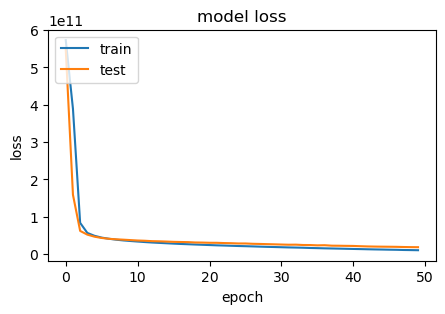

In [69]:
## Model Loss
plt.figure(figsize = (5,3))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

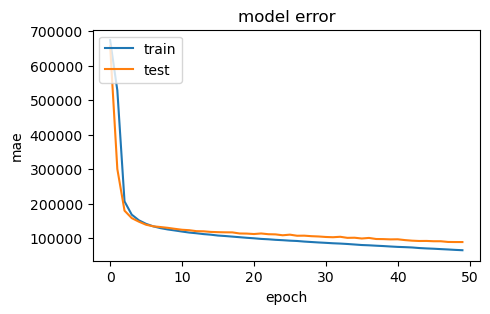

In [70]:
plt.figure(figsize=(5,3))
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.title('model error')
plt.ylabel('mae')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

### Hyper parameter tuning for xgboost 

In [71]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

random_search = RandomizedSearchCV(
    estimator=xgb,   #  already created xgb model
    param_distributions=param_grid,
    n_iter=10,       # no.of iterations
    cv=2,            # fold validation
    verbose=2,
    random_state=42,
    n_jobs=1         
)

random_search.fit(X_train_transformed, y_train)

Fitting 2 folds for each of 10 candidates, totalling 20 fits
[CV] END colsample_bytree=1, learning_rate=0.1, max_depth=4, n_estimators=300, subsample=1; total time=  26.4s
[CV] END colsample_bytree=1, learning_rate=0.1, max_depth=4, n_estimators=300, subsample=1; total time=  24.8s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=6, n_estimators=300, subsample=0.8; total time=  34.4s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=6, n_estimators=300, subsample=0.8; total time=  34.7s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimators=300, subsample=0.8; total time=  27.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimators=300, subsample=0.8; total time=  27.0s
[CV] END colsample_bytree=1, learning_rate=0.1, max_depth=6, n_estimators=300, subsample=1; total time=  31.9s
[CV] END colsample_bytree=1, learning_rate=0.1, max_depth=6, n_estimators=300, subsample=1; total time=  32.2s
[CV] END colsample_bytree=1, le

,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 1], 'learning_rate': [0.05, 0.1, ...], 'max_depth': [4, 6, ...], 'n_estimators': [100, 200, ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,1
,refit,True
,cv,2
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [72]:
print("Best Params:", random_search.best_params_)
best_xgb = random_search.best_estimator_

Best Params: {'subsample': 1, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 1}


In [73]:
# Predictions on training
yhat_train_best = best_xgb.predict(X_train_transformed)
# Evaluation
eval_regression(y_train, yhat_train_best)

mean squared error (MSE): 3009276416.0
 Root mean squared error (RMSE): 54856.87109375
R- squared value : 0.9746


In [74]:
# Predictions on testing
yhat_test_best = best_xgb.predict(X_test_transformed)
# Evaluation
eval_regression(y_test, yhat_test_best)

mean squared error (MSE): 7709917184.0
 Root mean squared error (RMSE): 87806.1328125
R- squared value : 0.9364


### Model Comparision 

In [75]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Desicion Tree Regressor", "Random Forest Regressor", "XGBoost", "Deep Learning(ANN)","Hyper param tuning(XGB)"],
    "RMSE": [145460, 155451.25, 152047.64, 91107.65, 138736.203125,87806.1328125] ,
    "R2": [0.8256, 0.8008, 0.8094, 0.9316, 0.8413,0.9364] 
})

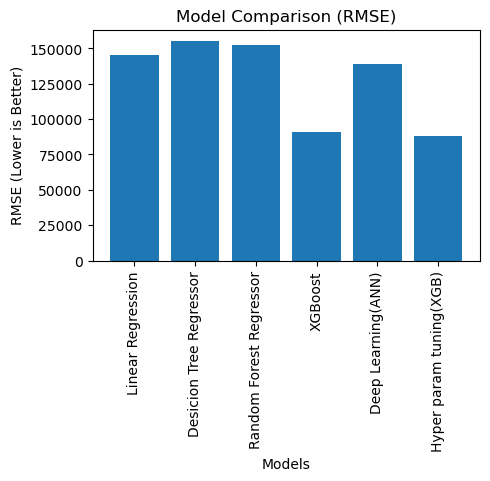

In [76]:
## Simple RMSE Graph 

plt.figure(figsize = (5,3))

plt.bar(results_df["Model"], results_df["RMSE"])

plt.title("Model Comparison (RMSE)")
plt.xlabel("Models")
plt.ylabel("RMSE (Lower is Better)")

plt.xticks(rotation=90) 
plt.show()

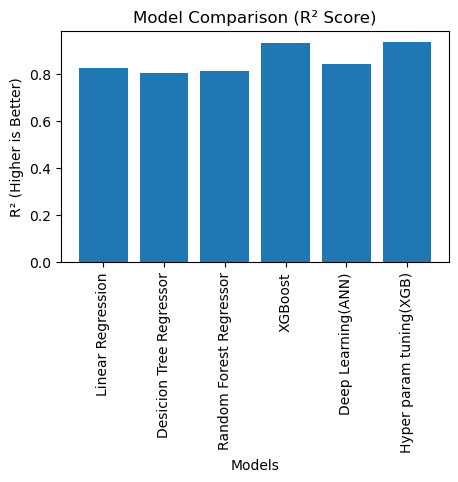

In [77]:
## simple R² Graph
plt.figure(figsize = (5,3))

plt.bar(results_df["Model"], results_df["R2"])

plt.title("Model Comparison (R² Score)")
plt.xlabel("Models")
plt.ylabel("R² (Higher is Better)")

plt.xticks(rotation=90)

plt.show()


### Conclusion 

> "Initially, I trained multiple models including Linear Regression,Decision Tree Regressor, Random Forest Regressor, XGBoost, and ANN. After evaluation, I applied hyperparameter tuning on XGBoost using technique RandomSearchCV. The tuned XGBoost significantly improved performance compared to other models based on RMSE and R² on test data."

In [78]:
import joblib
joblib.dump(xgb, 'xgb_model.pkl') # Replace model_4 with your model variable
joblib.dump(transformer, 'preprocessor.pkl') # Export your ColumnTransformer

['preprocessor.pkl']